# Retrieve chembl data

The purpose of this notebook is to retrieve all compounds on Chembl with measured hepatocyte stability readouts (intrinsic clearance).

In [ ]:
from pathlib import Path
import pathlib
import csv
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

Protein and data variables.

In [2]:
readout = 'hep_clint'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

### Download ligands and bioactivity data from Chembl.

In [ ]:
from chembl_webresource_client.new_client import new_client
import concurrent.futures

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [5]:
########## 1. Query all activities ##########

clint_readouts = ['CL'] # readouts can vary by Chembl version so these may not work for future versions.
all_activities = []

print("Fetching activities...")

for clint_readout in clint_readouts:
    activities = tqdm(new_client.activity.filter(
        standard_type=clint_readout,
        # target_organism__in=['Homo sapiens'],
        relation='='
    ).only(
        "activity_id",
        "assay_chembl_id",
        "molecule_chembl_id",
        "standard_type",
        "standard_units",
        "relation",
        "standard_value",
        "target_chembl_id",
    ))
    all_activities.extend(activities)

print(f"Total activities fetched: {len(all_activities)}")


Fetching activities...


  0%|          | 0/66385 [00:00<?, ?it/s]

Total activities fetched: 66385


In [6]:
########## 2. Helper to use the fetched Chembl records to query for all relevant data associated with them ##########

def process_activity(act):
    record = {
        "activity_id": act.get("activity_id"),
        "assay_chembl_id": act.get("assay_chembl_id"),
        "molecule_chembl_id": act.get("molecule_chembl_id"),
        "type": act.get("standard_type"),
        "standard_units": act.get("standard_units"),
        "relation": act.get("relation"),
        "standard_value": act.get("standard_value"),
        "target_chembl_id": act.get("target_chembl_id"),
        "target_organism": None,
        "assay_description": None,
        "assay_type": None,
        "smiles": None
    }

    try:
        assay = new_client.assay.get(act["assay_chembl_id"])
        record["assay_description"] = assay.get("description")
        record["assay_type"] = assay.get("assay_type")

        molecule = new_client.molecule.get(act["molecule_chembl_id"])
        if molecule and molecule.get("molecule_structures"):
            record["smiles"] = molecule["molecule_structures"].get("canonical_smiles")

        if act.get("target_chembl_id"):
            target = new_client.target.get(act["target_chembl_id"])
            record["target_organism"] = target.get("organism")

    except Exception as e:
        record["error"] = str(e)

    return record


In [7]:
########## 3. Code to run the query in parallel ##########

results = []
max_workers = 20

print("Processing records...")

def init_worker_cache():
    import requests_cache
    requests_cache.install_cache('chembl_cache', backend='sqlite', expire_after=7*24*60*60)

with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers, initializer=init_worker_cache) as executor:
    results = list(tqdm(executor.map(process_activity, all_activities), total=len(all_activities)))


print("Done!")


Processing records...


  0%|          | 0/66385 [00:00<?, ?it/s]

Done!


In [29]:
len(results)

66385

In [ ]:
# De-duplication

unique_activities = list({a["activity_id"]: a for a in results}.values())

In [ ]:
df = pd.DataFrame(unique_activities)
df['standard_value'] = df['standard_value'].astype(float)

/tmp/ipykernel_7590/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels
/tmp/ipykernel_7590/1747405060.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x labels


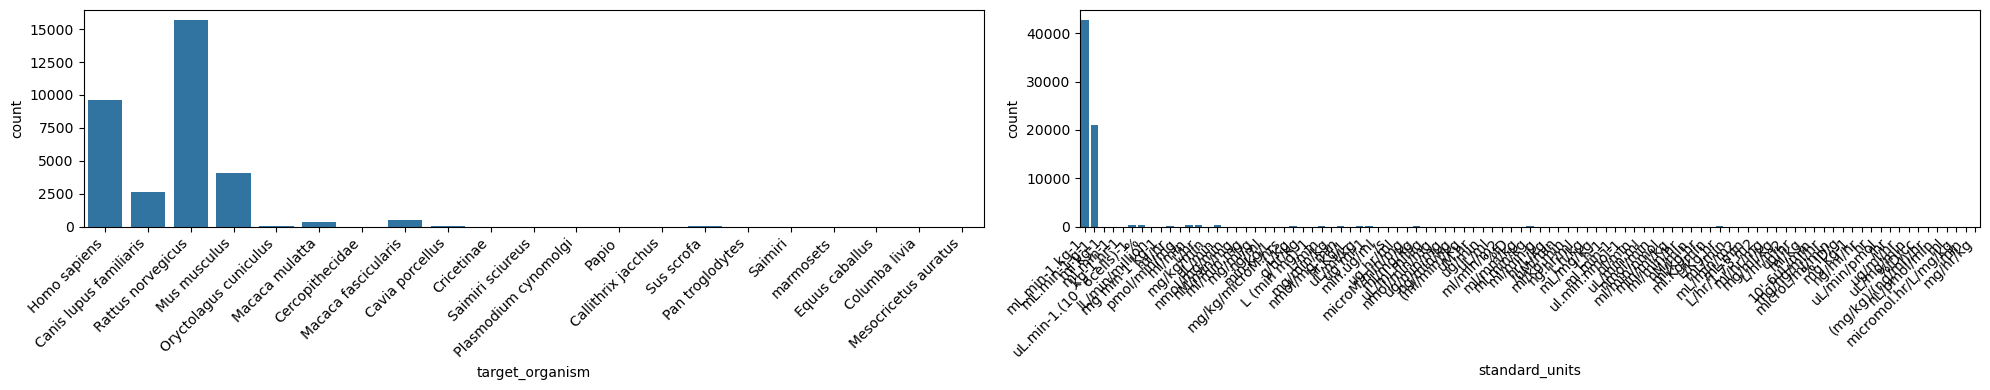

In [ ]:
cols = ["target_organism", "standard_units"]
f, axs = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axs, cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

f.tight_layout()

Let's keep and train on vivo clint (ml/min/kg). We'll need to convert those with units of ml/min/g by dividing by 1000.  

In [72]:
clint_df = df[(df['standard_units'] == 'mL.min-1.g-1') | (df['standard_units'] == 'mL.min-1.kg-1')]
len(clint_df)

63604

In [73]:
clint_df = clint_df.assign(
    clint = np.where(clint_df['standard_units'] == 'mL.min-1.g-1', clint_df['standard_value'] / 1000, clint_df['standard_value']),
    units = 'mL.min-1.kg-1'
)

clint_df.head()

,activity_id,assay_chembl_id,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism,assay_description,assay_type,smiles,clint,units
0,33031,CHEMBL695026,CHEMBL306457,CL,mL.min-1.kg-1,=,47.7,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,47.7,mL.min-1.kg-1
1,34270,CHEMBL695026,CHEMBL66457,CL,mL.min-1.kg-1,=,4.9,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,4.9,mL.min-1.kg-1
2,34274,CHEMBL695026,CHEMBL304053,CL,mL.min-1.kg-1,=,16.5,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,16.5,mL.min-1.kg-1
3,35507,CHEMBL695026,CHEMBL68366,CL,mL.min-1.kg-1,=,8.0,CHEMBL372,Homo sapiens,In vitro oxidative metabolic stability measure...,F,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,8.0,mL.min-1.kg-1
4,35511,CHEMBL618475,CHEMBL68366,CL,mL.min-1.kg-1,=,12.0,CHEMBL373,Canis lupus familiaris,Plasma clearance of compound was determined in...,A,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,12.0,mL.min-1.kg-1


We will consider Clint > 500 to be unreliable and omit them.

In [74]:
clint_df = clint_df[clint_df['clint'] < 500]
len(clint_df)

61661

<Axes: xlabel='clint', ylabel='Count'>

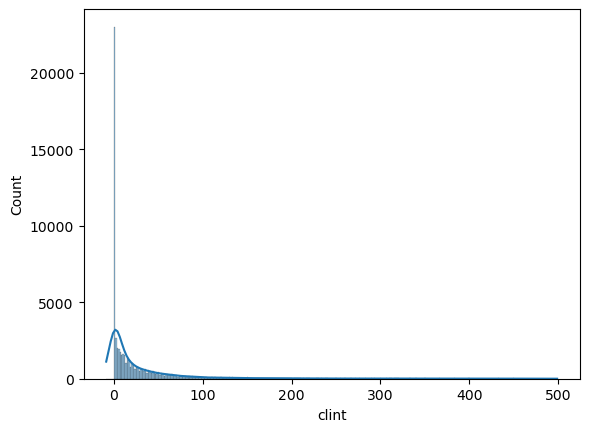

In [75]:
sns.histplot(data=clint_df, x="clint", kde=True)

Now separate heps and microsomes by species.

In [ ]:
def classify_assays(df):
    """
    Classify assays by hepatocyte/microsome type and species,
    and also tag records with species-only info if no cell system is detected.
    """

    # Core patterns
    hepatocyte_keywords = [
        r'\bhepatocyte\b', r'\bhepatocytes\b', r'\bhepatocellular\b',
        r'\bhepatoma\b', r'\bhep.*cell\b', r'\bhepg2\b', r'\bheparg\b',
        r'\bprimary hepatocyte\b', r'\bsandwich\b', r'\bhlc\b', r'\bs9\b',
        r'\bcultured hepatocyte\b', r'\bhepatocyte suspension\b'
    ]

    microsome_keywords = [
        r'\bmicrosome\b', r'\bmicrosomes\b', r'\bmicrosomal\b',
        r'\bHLM\b', r'\bRLM\b', r'\bMLM\b',
        r'\bmicrosomal clearance\b', r'\bmicrosomal incubation\b',
        r'\bpooled microsome\b'
    ]

    species_patterns = {
        'human': [
            r'\bhuman\b', r'\bvolunteer\b', r'\bsubject\b'
        ],
        'rat': [
            r'\brat\b', r'\bsprague[- ]?dawley\b', r'\bwistar\b',
            r'\bf344\b', r'\blewis\b'
        ],
        'mouse': [
            r'\bmouse\b', r'\bmice\b', r'\bcd[- ]?1\b', r'\bc57bl\b', r'\bBALB/c\b'
        ],
        'dog': [
            r'\bdog\b', r'\bcanine\b', r'\bbeagle\b'
        ],
        'monkey': [
            r'\bmonkey\b', r'\bcynomolgus\b', r'\brhesus\b', r'\bmacaca\b'
        ]
    }

    hep_pattern = re.compile('|'.join(hepatocyte_keywords), re.IGNORECASE)
    mic_pattern = re.compile('|'.join(microsome_keywords), re.IGNORECASE)
    species_patterns_compiled = {
        sp: re.compile('|'.join(pats), re.IGNORECASE)
        for sp, pats in species_patterns.items()
    }

    def detect_species(text):
        for sp, pat in species_patterns_compiled.items():
            if pat.search(text):
                return sp
        return None

    def classify_row(row):
        desc  = str(row.get('assay_description', ''))
        tissue = str(row.get('assay_tissue', ''))
        cell = str(row.get('cell_type', ''))
        comment = str(row.get('assay_comment', ''))
        organism = str(row.get('target_organism', ''))
        text_all = ' '.join([desc, tissue, cell, comment, organism])

        is_hep = bool(hep_pattern.search(text_all))
        is_mic = bool(mic_pattern.search(text_all))
        species = detect_species(text_all)

        # If hepatocyte/microsome detected
        if is_hep or is_mic:
            if not species:
                species = 'other'
            if is_hep and not is_mic:
                return f'hepatocyte_{species}'
            elif is_mic and not is_hep:
                return f'microsome_{species}'
            elif is_hep and is_mic:
                # tie-break using field context
                if hep_pattern.search(cell) or hep_pattern.search(tissue):
                    return f'hepatocyte_{species}'
                if mic_pattern.search(cell) or mic_pattern.search(tissue):
                    return f'microsome_{species}'
                return 'mixed'

        # If no hepatocyte/microsome, but species mentioned
        if species:
            return f'species_only_{species}'

        # Nothing matched
        return None

    df = df.copy()
    df['assay_class'] = df.apply(classify_row, axis=1)
    return df


In [109]:
classified_df = classify_assays(clint_df)
classified_df['assay_class'].value_counts(dropna=False)

assay_class
species_only_rat       16680
microsome_human        15023
microsome_rat           6358
microsome_mouse         6113
species_only_mouse      5520
species_only_dog        3491
species_only_human      2679
species_only_monkey     1511
None                     965
hepatocyte_human         961
hepatocyte_rat           930
microsome_dog            543
hepatocyte_mouse         344
microsome_monkey         268
hepatocyte_dog           107
microsome_other           85
hepatocyte_monkey         66
hepatocyte_other          14
mixed                      3
Name: count, dtype: int64

In [112]:
# Save the entire dataset
classified_df.to_csv(DATA / f"{readout}_all_species_and_endpoints_chembl.csv", index=False)

for assay_class, subset_df in classified_df.groupby("assay_class"):
    safe_name = str(assay_class) if pd.notna(assay_class) else "None"
    safe_name = safe_name.replace(" ", "_")
    subset_df.to_csv(DATA / f"{readout}_{safe_name}_chembl.csv", index=False)

print("All CSV files saved successfully.")


All CSV files saved successfully.
